# Photon Count & Fluence

**Purpose:** Characterise the detected photon population from MCX simulations across
chest-wall thicknesses (10–35 mm) and source–detector separations (SDS 5–35 mm).

**Analysis pipeline:**
1. Load simulation data (`detp` arrays) for each chest-wall thickness
2. Count detected photons per detector and per tissue layer
3. Compute **air-hit percentage** — the fraction of detected photons that traversed the lung air space
4. Visualise counts, layer fractions, and SDS/CW trends

---
**`detp` row mapping (MCX output):**

| Row | Content |
|-----|---------|
| 0 | Detector ID (1-based) |
| 1 | Lung tissue step count |
| 2 | Air (lung gas) step count |
| 3 | Chest-wall (thorax) step count |

A photon **hit air** if its air step count (row 2) > 0.
Only these photons carry the GASMAS O₂ absorption signal.


## 1. Environment Setup


In [ ]:
%pip install --upgrade matplotlib pyparsing

# Mount Google Drive (comment out if running locally)
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Global parameters ────────────────────────────────────────────────
SDS_LIST_MM     = [10,20,30,40,50,60,70]   # source-detector separations [mm]
CW_THICKNESSES  = [10,20,30]       # chest-wall thicknesses [mm]
CW_LABELS       = [f'{t} mm' for t in CW_THICKNESSES]
DATA_ROOT       = '/content/drive/MyDrive/GASMAS_Corrected/OR_3'

# Colour map shared across all multi-CW plots
CMAP = plt.cm.tab10
CW_COLORS = {f'{t}mm': CMAP(i / 8) for i, t in enumerate(CW_THICKNESSES)}


## 2. Load MCX Simulation Data

Each `.npz` file contains the `detp` detected-photon array and the `fluence` volume.
We load all chest-wall thicknesses into a single dictionary for clean downstream access.


In [ ]:
detp_raw    = {}
fluence_raw = {}

for t in CW_THICKNESSES:
    key  = f'{t}mm'
    path = f'{DATA_ROOT}/gasmas_internal_probe_results_{t}mm.npz'
    with np.load(path) as d:
        detp_raw[key]    = d['detp'].copy()
        fluence_raw[key] = d['fluence'].copy()
    print(f'  Loaded {key}: {detp_raw[key].shape[1]:,} total detected photons')

print(f'\nAll datasets loaded: {list(detp_raw.keys())}')


  Loaded 10mm: 65,745 total detected photons
  Loaded 20mm: 66,320 total detected photons
  Loaded 30mm: 64,757 total detected photons

All datasets loaded: ['10mm', '20mm', '30mm']


## 3. Group Photons by Detector & Compute Layer Counts

Each detected photon is assigned to a detector via row 0 of `detp`.
For each detector we count how many photons visited each tissue layer,
and how many were **thorax-only** (never reached lung or air).


In [ ]:
def group_by_detector(detp):
    """Split detp columns by detector ID. Returns {det_id: detp_subset}."""
    out = {}
    for det_id in np.unique(detp[0].astype(int)):
        out[det_id] = detp[:, detp[0].astype(int) == det_id]
    return out


def layer_counts(grouped):
    """
    For each detector compute photon counts per layer and air-hit percentage.

    Returns list of dicts (one per detector, ordered by det_id):
      det_id, sds, n_total, n_lung, n_air, n_thorax, n_thorax_only,
      pct_air, pct_lung, pct_thorax, pct_thorax_only
    """
    rows = []
    for det_id in sorted(grouped.keys()):
        ph = grouped[det_id]
        n_tot          = ph.shape[1]
        n_lung         = int(np.count_nonzero(ph[1] > 0))
        n_air          = int(np.count_nonzero(ph[2] > 0))
        n_thorax       = int(np.count_nonzero(ph[3] > 0))
        n_thorax_only  = int(np.count_nonzero(
                            (ph[3] > 0) & (ph[2] == 0) & (ph[1] == 0)))

        sds = SDS_LIST_MM[det_id - 1] if det_id - 1 < len(SDS_LIST_MM) else None

        def pct(n): return 100.0 * n / n_tot if n_tot > 0 else 0.0

        rows.append({
            'det_id'        : det_id,
            'sds'           : sds,
            'n_total'       : n_tot,
            'n_lung'        : n_lung,
            'n_air'         : n_air,
            'n_thorax'      : n_thorax,
            'n_thorax_only' : n_thorax_only,
            'pct_air'       : pct(n_air),
            'pct_lung'      : pct(n_lung),
            'pct_thorax'    : pct(n_thorax),
            'pct_thorax_only': pct(n_thorax_only),
        })
    return rows


# Group and compute for every CW thickness
detp_grouped = {k: group_by_detector(v) for k, v in detp_raw.items()}
counts       = {k: layer_counts(detp_grouped[k]) for k in detp_grouped}

print('Photon grouping complete.')


Photon grouping complete.


## 4. Photon Count Summary Tables

Full breakdown per detector and chest-wall thickness.
**Air-hit %** is the key metric: it tells us what fraction of detected photons
carried the GASMAS O₂ signal.


In [ ]:
HDR = (f"{'CW':<6} {'SDS':>5}  {'N_total':>9}  {'N_air':>8}  "
       f"{'Air %':>7}  {'N_lung':>8}  {'Lung %':>7}  "
       f"{'N_thorax':>9}  {'Thorax %':>9}  {'N_thorax_only':>14}  {'ThoraxOnly %':>13}")

print(HDR)
print('=' * len(HDR))

for cw in sorted(counts.keys()):
    for r in counts[cw]:
        print(
            f"{cw:<6} {r['sds']:>5}  {r['n_total']:>9,}  {r['n_air']:>8,}  "
            f"{r['pct_air']:>6.2f}%  {r['n_lung']:>8,}  {r['pct_lung']:>6.2f}%  "
            f"{r['n_thorax']:>9,}  {r['pct_thorax']:>8.2f}%  "
            f"{r['n_thorax_only']:>14,}  {r['pct_thorax_only']:>12.2f}%"
        )
    print()


CW       SDS    N_total     N_air    Air %    N_lung   Lung %   N_thorax   Thorax %   N_thorax_only   ThoraxOnly %
10mm      10        588       588  100.00%       588  100.00%        588    100.00%               0          0.00%
10mm      20      1,704     1,702   99.88%     1,702   99.88%      1,704    100.00%               2          0.12%
10mm      30      3,784     3,744   98.94%     3,756   99.26%      3,784    100.00%              28          0.74%
10mm      40      7,978     7,491   93.90%     7,584   95.06%      7,978    100.00%             394          4.94%
10mm      50     15,216    10,506   69.05%    10,972   72.11%     15,216    100.00%           4,244         27.89%
10mm      60     20,632     7,135   34.58%     7,604   36.86%     20,632    100.00%          13,028         63.14%
10mm      70     15,843     2,933   18.51%     3,167   19.99%     15,843    100.00%          12,676         80.01%

20mm      10        609       581   95.40%       585   96.06%        609    100

## 5. Visualisations

Five complementary plots:
- **5a** Total detected photon counts vs. SDS
- **5b** Air-hit photon counts vs. SDS
- **5c** **Air-hit percentage** vs. SDS ← key new analysis
- **5d** Stacked-bar breakdown of layer fractions per detector
- **5e** Thorax-only photon counts vs. SDS (noise / background)


### 5a. Total Detected Photon Counts vs. SDS

Photon counts fall with SDS as fewer photons reach distant detectors.
Thicker chest walls attenuate more strongly, especially at large SDS.


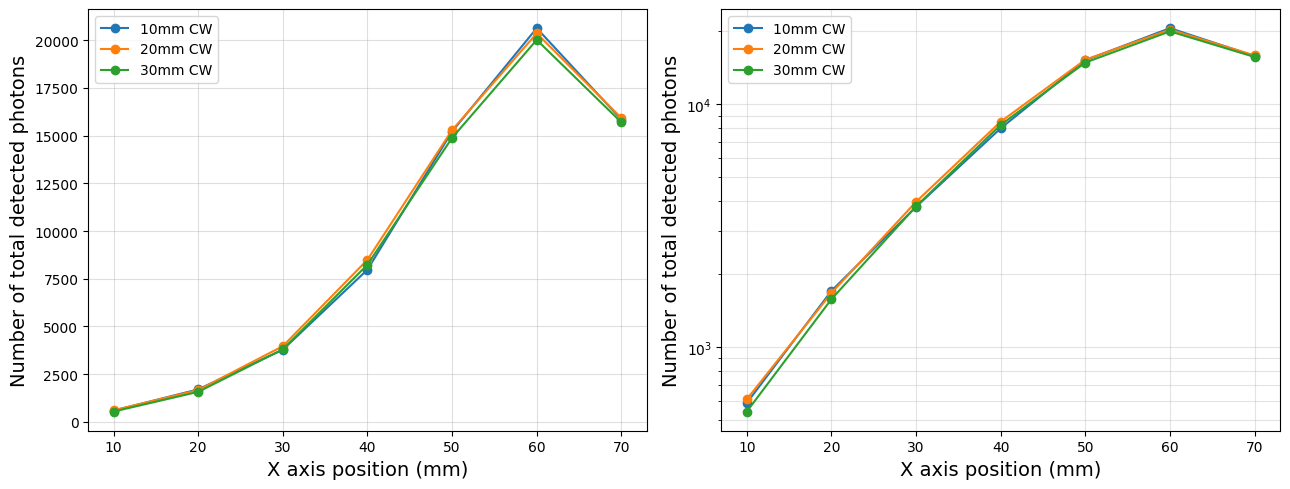

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yscale in zip(axes, ['linear', 'log']):
    for cw in sorted(counts.keys()):
        sds_vals = [r['sds']     for r in counts[cw]]
        n_vals   = [r['n_total'] for r in counts[cw]]
        ax.plot(sds_vals, n_vals, marker='o',
                color=CW_COLORS[cw], label=f'{cw} CW')
    ax.set_xlabel('X axis position (mm)',fontsize=14)
    ax.set_ylabel('Number of total detected photons',fontsize=14)
    ax.set_yscale(yscale)
    #ax.set_title(f'Total Detected Photons vs. SDS  ({yscale} scale)')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.4)
    if yscale == 'log':
        ax.grid(True, which='both', alpha=0.35)

plt.tight_layout(); plt.show()


### 5b. Air-Hit Photon Counts vs. SDS

Photons that traversed the lung air space carry the GASMAS signal.
Their count determines the shot-noise floor on the O₂ measurement.


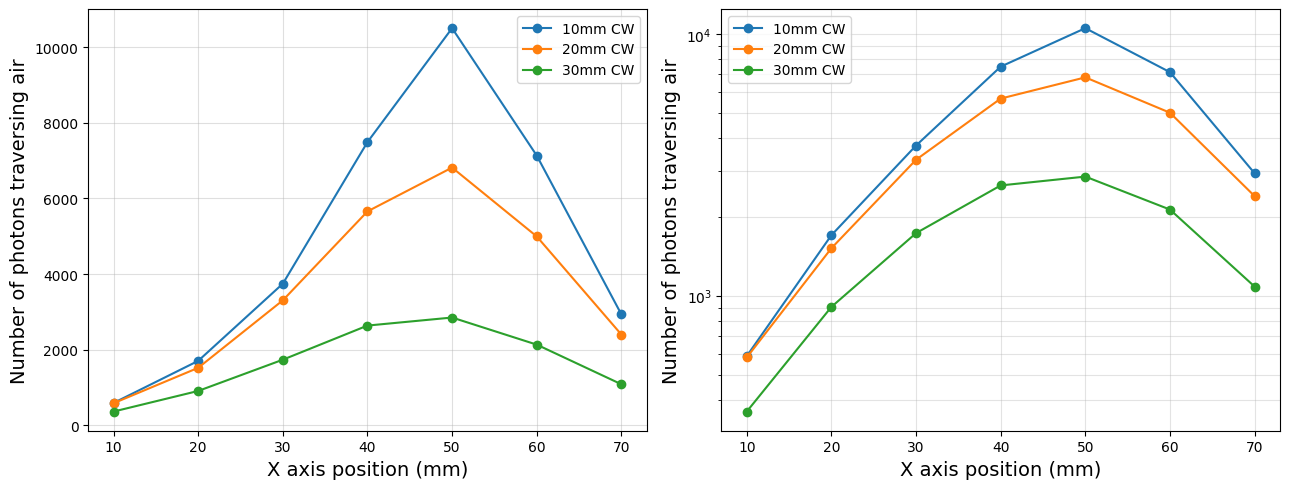

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yscale in zip(axes, ['linear', 'log']):
    for cw in sorted(counts.keys()):
        sds_vals  = [r['sds']   for r in counts[cw]]
        air_vals  = [r['n_air'] for r in counts[cw]]
        ax.plot(sds_vals, air_vals, marker='o',
                color=CW_COLORS[cw], label=f'{cw} CW')
    ax.set_xlabel('X axis position (mm)',fontsize=14)
    ax.set_ylabel('Number of photons traversing air', fontsize=14)
    ax.set_yscale(yscale)
    #ax.set_title(f'Air-Hit Photon Counts vs. SDS  ({yscale} scale)')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.4)
    if yscale == 'log':
        ax.grid(True, which='both', alpha=0.35)

plt.tight_layout(); plt.show()


### 5c. Air-Hit Percentage vs. SDS  ← Key New Analysis

This shows what **fraction** of detected photons actually sampled the lung air space,
as a function of SDS and chest-wall thickness.

- At short SDS, photons are confined to the chest wall → low air-hit %
- Air-hit % peaks at some intermediate SDS where the banana-shaped
  photon path reaches maximum lung overlap
- Beyond the peak, total counts drop faster than air counts (deeper paths
  are increasingly filtered out), potentially raising the fraction again
- Thicker chest walls consistently suppress the air-hit fraction


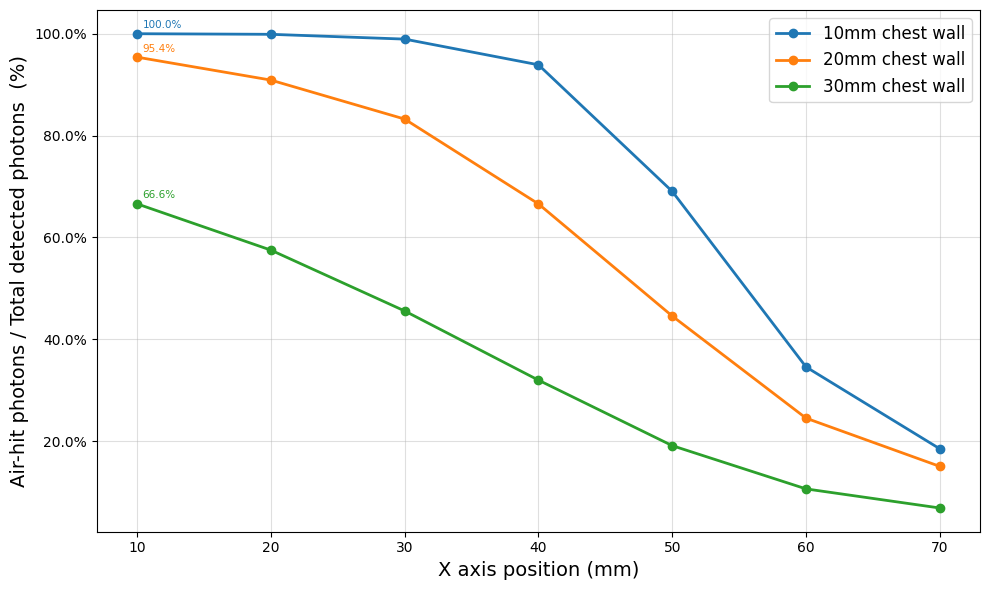

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for cw in sorted(counts.keys()):
    sds_vals = [r['sds']     for r in counts[cw]]
    pct_vals = [r['pct_air'] for r in counts[cw]]
    ax.plot(sds_vals, pct_vals, marker='o', lw=2,
            color=CW_COLORS[cw], label=f'{cw} chest wall')

    # Annotate peak
    peak_idx = int(np.argmax(pct_vals))
    ax.annotate(
        f"{pct_vals[peak_idx]:.1f}%",
        xy=(sds_vals[peak_idx], pct_vals[peak_idx]),
        xytext=(4, 4), textcoords='offset points',
        fontsize=7.5, color=CW_COLORS[cw]
    )

ax.set_xlabel('X axis position (mm)', fontsize=14)
ax.set_ylabel('Air-hit photons / Total detected photons  (%)', fontsize=14)
#ax.set_title('Percentage of Detected Photons that Traversed the Lung Air Space',
#             fontsize=13)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(fontsize=12, loc='best')
ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()


#### All-Layer Percentage Breakdown per Chest-Wall Thickness

Each subplot shows how the four fractions (air, lung, thorax, thorax-only) evolve
with SDS for one chest-wall thickness.


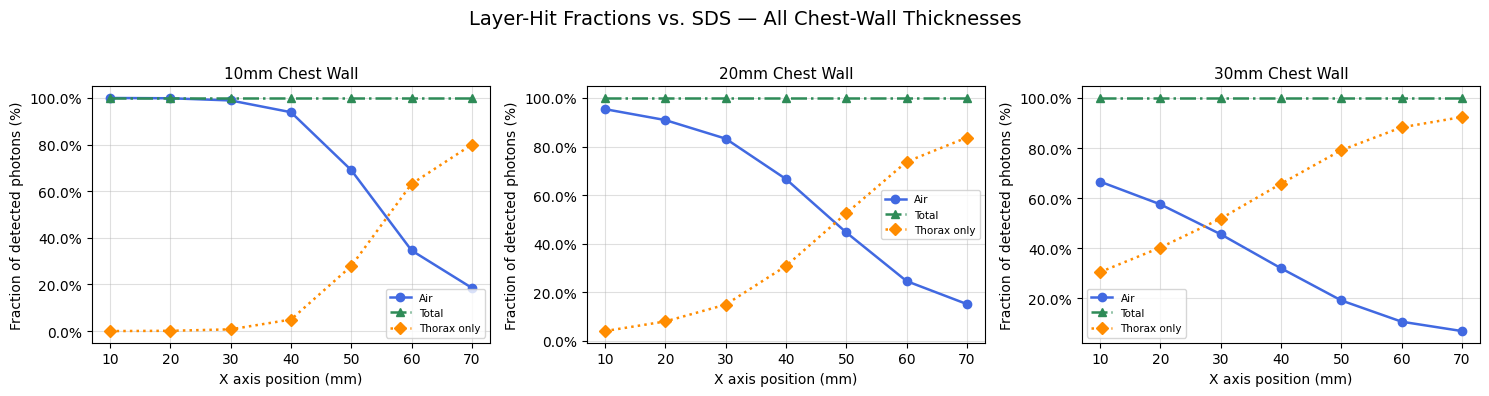

In [ ]:
cw_list = sorted(counts.keys())
n_cw    = len(cw_list)
cols    = 3;  rows = (n_cw + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), squeeze=False)
axes = axes.flatten()

layer_styles = [
    ('pct_air',          'Air',          'royalblue',  'o', '-'),
    #('pct_lung',         'Lung',         'tomato',     's', '--'),
    ('pct_thorax',       'Total',       'seagreen',   '^', '-.'),
    ('pct_thorax_only',  'Thorax only',  'darkorange',  'D', ':'),
]

for idx, cw in enumerate(cw_list):
    ax       = axes[idx]
    sds_vals = [r['sds'] for r in counts[cw]]
    for key, label, color, marker, ls in layer_styles:
        pct_vals = [r[key] for r in counts[cw]]
        ax.plot(sds_vals, pct_vals, marker=marker, ls=ls,
                color=color, label=label, lw=1.8)
    ax.set_title(f'{cw} Chest Wall', fontsize=11)
    ax.set_xlabel('X axis position (mm)')
    ax.set_ylabel('Fraction of detected photons (%)')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    ax.legend(fontsize=7.5); ax.grid(True, alpha=0.4)

for j in range(idx+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Layer-Hit Fractions vs. SDS — All Chest-Wall Thicknesses',
             fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()


### 5e. Thorax-Only Photon Counts vs. SDS

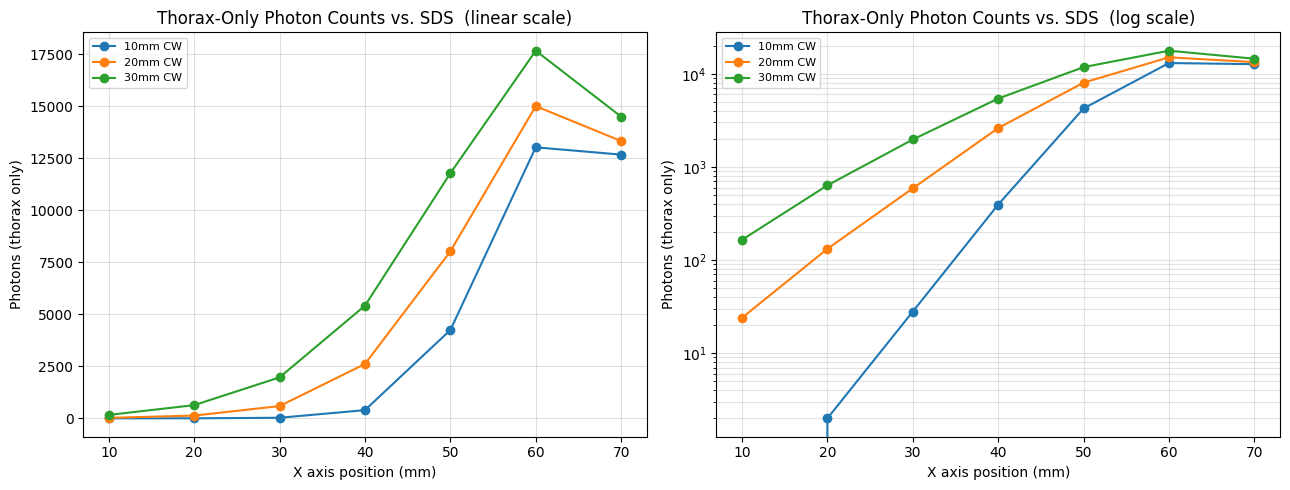

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, yscale in zip(axes, ['linear', 'log']):
    for cw in sorted(counts.keys()):
        sds_vals  = [r['sds']           for r in counts[cw]]
        tho_vals  = [r['n_thorax_only']  for r in counts[cw]]
        ax.plot(sds_vals, tho_vals, marker='o',
                color=CW_COLORS[cw], label=f'{cw} CW')
    ax.set_xlabel('X axis position (mm)')
    ax.set_ylabel('Photons (thorax only)')
    ax.set_yscale(yscale)
    ax.set_title(f'Thorax-Only Photon Counts vs. SDS  ({yscale} scale)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
    if yscale == 'log':
        ax.grid(True, which='both', alpha=0.35)

plt.tight_layout(); plt.show()


## 6. Air-Hit Percentage Heatmap (CW Thickness × SDS)


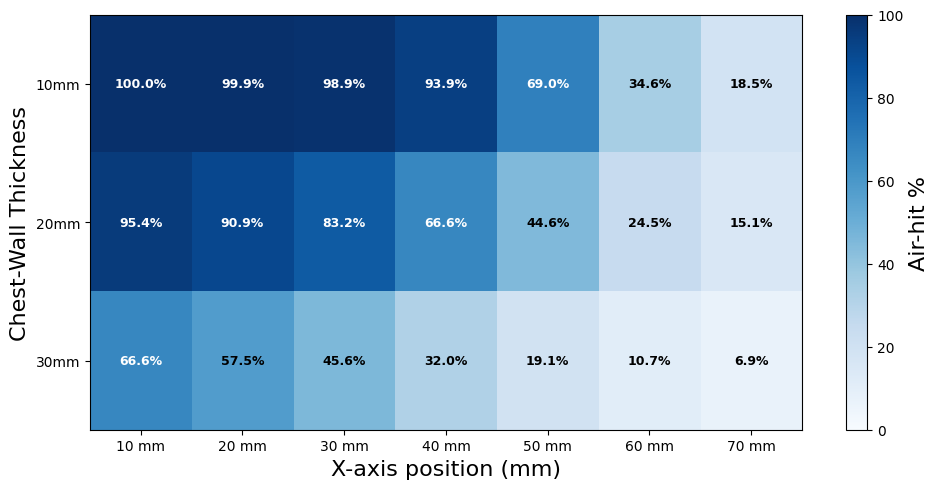

In [ ]:
cw_order  = sorted(counts.keys())   # 10mm … 35mm
n_cw      = len(cw_order)
n_sds     = len(SDS_LIST_MM)

heatmap = np.zeros((n_cw, n_sds))
for i, cw in enumerate(cw_order):
    for j, r in enumerate(counts[cw]):
        heatmap[i, j] = r['pct_air']

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(heatmap, aspect='auto', cmap='Blues', vmin=0)

ax.set_xticks(range(n_sds))
ax.set_xticklabels([f'{s} mm' for s in SDS_LIST_MM])
ax.set_yticks(range(n_cw))
ax.set_yticklabels(cw_order)
ax.set_xlabel('X-axis position (mm)',fontsize=16)
ax.set_ylabel('Chest-Wall Thickness',fontsize=16)
#ax.set_title('Air-Hit Percentage Heatmap  (% of detected photons that traversed lung air)')

# Annotate cells with the value
for i in range(n_cw):
    for j in range(n_sds):
        val = heatmap[i, j]
        txt_color = 'white' if val > heatmap.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=9, color=txt_color, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='Air-hit %')
cbar.set_label('Air-hit %', fontsize=16)
plt.tight_layout(); plt.show()

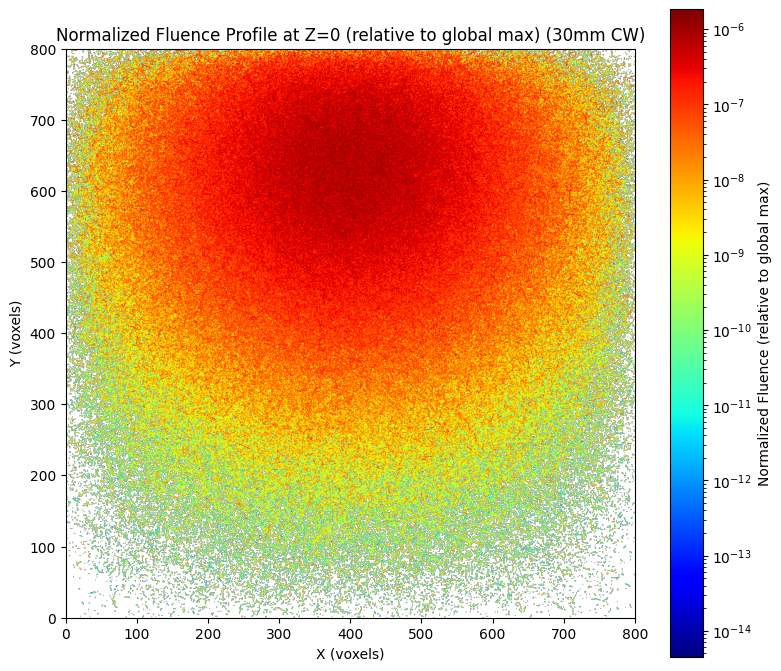

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors

# Choose one chest-wall thickness for demonstration
cw_key = '30mm'
fluence_data = fluence_raw[cw_key]

# Get dimensions (assuming X, Y, Z order for fluence_raw output)
dim_x, dim_y, dim_z = fluence_data.shape

# --- Global Normalization --- START
# Calculate the maximum fluence in the entire 3D cube
global_max_fluence = np.max(fluence_data)

# Normalize the entire fluence dataset by the global maximum
# Handle case where global_max_fluence might be zero to avoid division by zero
if global_max_fluence == 0:
    print("Warning: Global maximum fluence is zero. Cannot normalize. Plotting raw data.")
    normalized_fluence_data = fluence_data
    plot_title = f'Raw Fluence Profile at Z=0 ({cw_key} CW)'
    cmap_label = 'Raw Fluence (a.u.)'
else:
    normalized_fluence_data = fluence_data / global_max_fluence
    plot_title = f'Normalized Fluence Profile at Z=0 (relative to global max) ({cw_key} CW)'
    cmap_label = 'Normalized Fluence (relative to global max)'
# --- Global Normalization --- END

# --- Extract Fluence Profile at Z=0 --- START
# User requested fluence profile at Z=0 (which corresponds to index 0 in 0-based indexing)
# Ensure z_index is within bounds
z_profile_idx = 1
if not (0 <= z_profile_idx < dim_z):
    print(f"Error: Z-profile index {z_profile_idx} is out of bounds for Z-dimension {dim_z}. Using z=0 instead.")
    z_profile_idx = 0

# Get the 2D fluence profile at the specified Z-index
display_fluence = normalized_fluence_data[:, :, z_profile_idx]
# --- Extract Fluence Profile at Z=0 --- END


# Plot the 2D colormap
fig, ax = plt.subplots(figsize=(8, 7))

# --- Logarithmic Colormap --- START
# Ensure there are no zero or negative values for LogNorm
# Replace zeros with a very small positive number or filter them out if appropriate
# A common practice for visualization is to set a minimum threshold for log scale.
min_val = np.min(display_fluence[display_fluence > 0]) if np.min(display_fluence[display_fluence > 0]) > 0 else 1e-10

im = ax.imshow(display_fluence, cmap='jet', origin='lower',
               extent=[0, dim_x, 0, dim_y],
               norm=matplotlib.colors.LogNorm(vmin=min_val, vmax=display_fluence.max()))
# --- Logarithmic Colormap --- END

ax.set_xlabel('X (voxels)')
ax.set_ylabel('Y (voxels)')
ax.set_title(plot_title)
plt.colorbar(im, ax=ax, label=cmap_label)
plt.tight_layout()
plt.show()

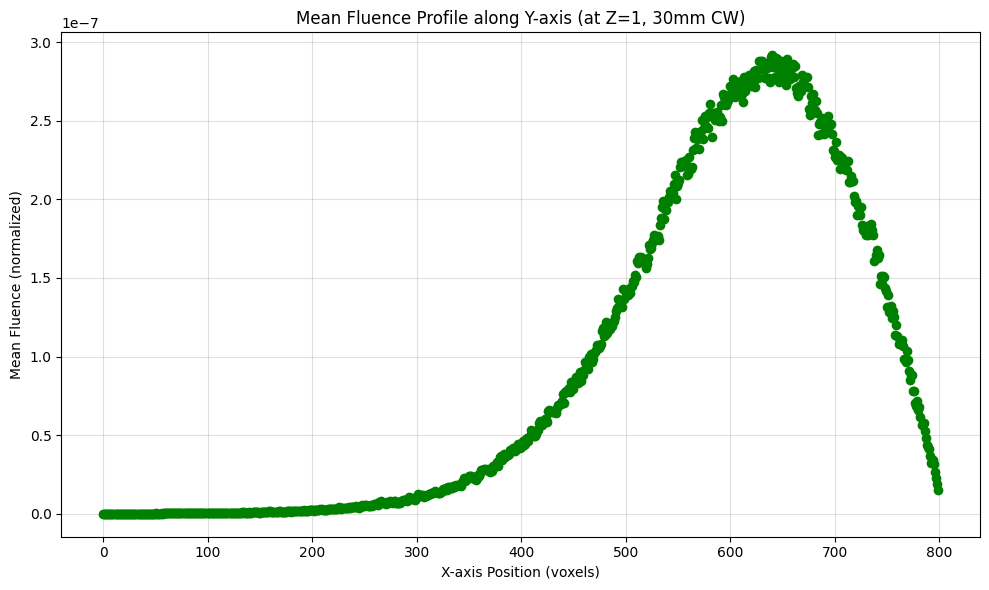

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure display_fluence, z_profile_idx, cw_key, dim_y are available from yaOw0aSYgwQY
# if not, the error message will guide the user.

if 'display_fluence' in globals() and isinstance(display_fluence, np.ndarray) and display_fluence.ndim == 2:
    # Project the 2D display_fluence profile (which has shape (dim_x, dim_y))
    # onto the y-axis. This means calculating the mean fluence for each y-position
    # by averaging across all x-positions (axis=0).
    mean_fluence_values = np.mean(display_fluence, axis=1)

    # The y-coordinates for plotting will correspond to the indices along the y-axis
    y_coordinates_for_plot = np.arange(display_fluence.shape[1]) # Use dim_y from display_fluence shape

    # Plotting with 'Mean Fluence' on the x-axis and 'Y-axis Position' on the y-axis
    plt.figure(figsize=(10, 6))
    plt.plot(y_coordinates_for_plot,mean_fluence_values, 'o', color='green')

    plt.ylabel('Mean Fluence (normalized)')
    plt.xlabel('X-axis Position (voxels)')
    plt.title(f'Mean Fluence Profile along Y-axis (at Z={z_profile_idx}, {cw_key} CW)')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'display_fluence' variable not found or not in expected 2D format. Please ensure cell yaOw0aSYgwQY was run correctly.")

### Skew-Normal Distribution Fit (Normalized)

This cell applies the skew-normal distribution fit again, but this time normalizing the fitted curve to its maximum value for better comparison with the data. The distribution is designed to handle asymmetry (skewness) in data, making it a good candidate for the 'left-skewed Gaussian' shape mentioned.

/tmp/ipykernel_17822/3412095626.py:33: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(skew_normal_pdf, y_data_for_fit, fluence_data_for_fit, p0=p0, maxfev=5000)


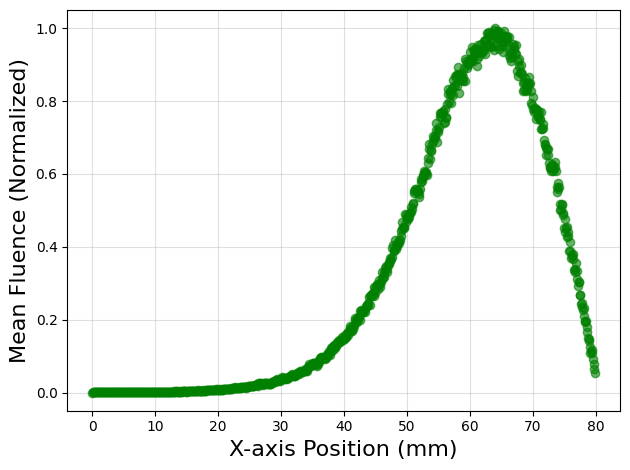

In [ ]:
from scipy.stats import skewnorm
from scipy.optimize import curve_fit

# Define the skew-normal PDF function
# The parameters are: x (data points), a (skewness), loc (location), scale (scale)
def skew_normal_pdf(x, a, loc, scale):
    return skewnorm.pdf(x, a, loc, scale)

# Ensure mean_fluence_values and y_coordinates_for_plot are available
if 'mean_fluence_values' in globals() and 'y_coordinates_for_plot' in globals():
    # Filter out zero or near-zero values from mean_fluence_values for better fitting
    # and corresponding y_coordinates. This helps `curve_fit` with distributions.
    # For fitting a PDF, the values should ideally be non-negative.
    # Using a small threshold to avoid issues with very small numbers.
    threshold = 1e-15 # adjust as needed
    mask = mean_fluence_values > threshold

    y_data_for_fit = y_coordinates_for_plot[mask]
    fluence_data_for_fit = mean_fluence_values[mask]

    # Initial guesses for the parameters (a, loc, scale)
    # a: skewness (can be positive or negative)
    # loc: approximate center of the distribution (e.g., mean or median of the data)
    # scale: spread of the distribution (e.g., standard deviation)
    initial_a = 0 # Start with a normal distribution assumption
    initial_loc = np.mean(y_data_for_fit) # or np.median(y_data_for_fit)
    initial_scale = np.std(y_data_for_fit) # or (np.max(y_data_for_fit) - np.min(y_data_for_fit)) / 4

    p0 = [initial_a, initial_loc, initial_scale]

    try:
        # Perform the curve fit
        params, covariance = curve_fit(skew_normal_pdf, y_data_for_fit, fluence_data_for_fit, p0=p0, maxfev=5000)

        # Extract optimized parameters
        a_fit, loc_fit, scale_fit = params

        # Generate the fitted curve using the optimized parameters
        y_fit = np.linspace(y_coordinates_for_plot.min(), y_coordinates_for_plot.max(), 500)
        skew_normal_fit_values = skew_normal_pdf(y_fit, a_fit, loc_fit, scale_fit)

        # --- Normalize the fitted curve by its maximum --- START
        max_fit_value = np.max(skew_normal_fit_values)
        if max_fit_value > 0:
            skew_normal_fit_values_normalized = skew_normal_fit_values / max_fit_value
        else:
            skew_normal_fit_values_normalized = skew_normal_fit_values # Avoid division by zero

        # Normalize the actual data for consistent comparison if not already normalized for plotting
        max_data_value = np.max(mean_fluence_values)
        if max_data_value > 0:
            mean_fluence_values_normalized = mean_fluence_values / max_data_value
        else:
            mean_fluence_values_normalized = mean_fluence_values
        # --- Normalize the fitted curve by its maximum --- END

        # --- Convert y-axis to mm --- START
        voxel_size_mm = 0.1 # mm per voxel
        y_coordinates_mm = y_coordinates_for_plot * voxel_size_mm
        y_fit_mm = y_fit * voxel_size_mm
        # --- Convert y-axis to mm --- END

        # Plotting
        plt.figure()
        plt.plot(y_coordinates_mm, mean_fluence_values_normalized, 'o', color='green', label='Mean Fluence Data (Normalized)', alpha=0.6)
        #plt.plot(y_fit_mm, skew_normal_fit_values_normalized, '-', color='blue', linewidth=2, label=f'Skew-Normal Fit (Normalized, a={a_fit:.2f}, loc={loc_fit:.2f}, scale={scale_fit:.2f})')

        plt.ylabel('Mean Fluence (Normalized)', fontsize=16)
        plt.xlabel('X-axis Position (mm)', fontsize=16)
        #plt.title(f'Mean Fluence Profile with Normalized Skew-Normal Fit (at Z={z_profile_idx}, {cw_key} CW)')
        plt.grid(True, alpha=0.4)
        #plt.legend()
        plt.tight_layout()
        plt.show()

    except RuntimeError as e:
        print(f"Error fitting skew-normal distribution: {e}")
        print("Consider adjusting initial parameter guesses or checking data quality.")

else:
    print("Error: 'mean_fluence_values' or 'y_coordinates_for_plot' not found. Please ensure preceding cells were run correctly.")